In [70]:
import pandas as pd

df = pd.read_csv("vehicles.csv")

In [71]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [72]:
df.shape

(426880, 18)

In [73]:
df.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [75]:
df.isnull().sum()

,0
id,0
region,0
price,0
year,1205
manufacturer,17646
model,5277
condition,174104
cylinders,177678
fuel,3013
odometer,4400


In [76]:
df.describe()

,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


In [77]:
cars = df.copy()

In [78]:
cars.columns

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN',
       'drive', 'size', 'type', 'paint_color', 'state'],
      dtype='object')

In [79]:
cars = cars.drop(columns=["id", "VIN", "region"])

In [80]:
cars.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [81]:
cars.isnull().sum().sort_values(ascending=False)

,0
size,306361
cylinders,177678
condition,174104
drive,130567
paint_color,130203
type,92858
manufacturer,17646
title_status,8242
model,5277
odometer,4400


In [82]:
cars = cars.drop(columns=["size"])

In [83]:
cars.shape

(426880, 14)

In [84]:
cars = cars.dropna(subset=["year", "odometer"])

In [85]:
cars.shape

(421344, 14)

In [86]:
cars = cars[(cars["price"] >= 500) & (cars["price"] <= 100000)]
#Listings with prices below $500 or above $100,000 were removed because they likely represented placeholders,
#data-entry errors, or unusually specialized vehicles that were not representative of a typical used-car dealership.

In [87]:
cars.shape

(380907, 14)

In [88]:
cars = cars[(cars["odometer"] > 0) & (cars["odometer"] <= 300000)]

In [89]:
cars.shape

(377164, 14)

In [90]:
cars = cars[(cars["year"] >= 1990) & (cars["year"] <= 2022)]

In [91]:
cars.shape

(365951, 14)

In [92]:
cars.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state
27,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,NaN,pickup,white,al
28,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,NaN,pickup,blue,al
29,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,NaN,pickup,red,al
30,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,NaN,pickup,red,al
31,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al


In [93]:
categorical_columns = cars.select_dtypes(include="object").columns

cars[categorical_columns] = cars[categorical_columns].fillna("unknown")

In [94]:
cars.isnull().sum()

,0
price,0
year,0
manufacturer,0
model,0
condition,0
cylinders,0
fuel,0
odometer,0
title_status,0
transmission,0


In [95]:
cars["year"] = cars["year"].astype(int)

In [96]:
cars["vehicle_age"] = 2022 - cars["year"]

In [97]:
cars.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,vehicle_age
27,33590,2014,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,unknown,pickup,white,al,8
28,22590,2010,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,unknown,pickup,blue,al,12
29,39590,2020,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,unknown,pickup,red,al,2
30,30990,2017,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,unknown,pickup,red,al,5
31,15000,2013,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,9


In [98]:
cars.duplicated().sum()

np.int64(108551)

In [99]:
cars = cars.drop_duplicates()

In [100]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 257400 entries, 27 to 426879
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         257400 non-null  int64  
 1   year          257400 non-null  int64  
 2   manufacturer  257400 non-null  object 
 3   model         257400 non-null  object 
 4   condition     257400 non-null  object 
 5   cylinders     257400 non-null  object 
 6   fuel          257400 non-null  object 
 7   odometer      257400 non-null  float64
 8   title_status  257400 non-null  object 
 9   transmission  257400 non-null  object 
 10  drive         257400 non-null  object 
 11  type          257400 non-null  object 
 12  paint_color   257400 non-null  object 
 13  state         257400 non-null  object 
 14  vehicle_age   257400 non-null  int64  
dtypes: float64(1), int64(3), object(11)
memory usage: 31.4+ MB


In [101]:
cars.describe()

,price,year,odometer,vehicle_age
count,257400.000000,257400.000000,257400.000000,257400.000000
mean,17921.099934,2011.712280,97507.525598,10.287720
std,14099.451042,6.064004,62824.072168,6.064004
min,500.000000,1990.000000,1.000000,0.000000
25%,6995.000000,2008.000000,43000.000000,5.000000
50%,14000.000000,2013.000000,94000.000000,9.000000
75%,25990.000000,2017.000000,141000.000000,14.000000
max,100000.000000,2022.000000,300000.000000,32.000000


In [102]:
cars.head()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,vehicle_age
27,33590,2014,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,unknown,pickup,white,al,8
28,22590,2010,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,unknown,pickup,blue,al,12
29,39590,2020,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,unknown,pickup,red,al,2
30,30990,2017,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,unknown,pickup,red,al,5
31,15000,2013,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,9


In [103]:
print("Original shape:", df.shape)
print("Cleaned shape:", cars.shape)

Original shape: (426880, 18)
Cleaned shape: (257400, 15)


**After cleaning, the dataset contains 179767 vehicles and 15 features. The summary statistics show that unrealistic values and missing observations have been removed, making the data suitable for exploratory analysis and predictive modeling.**

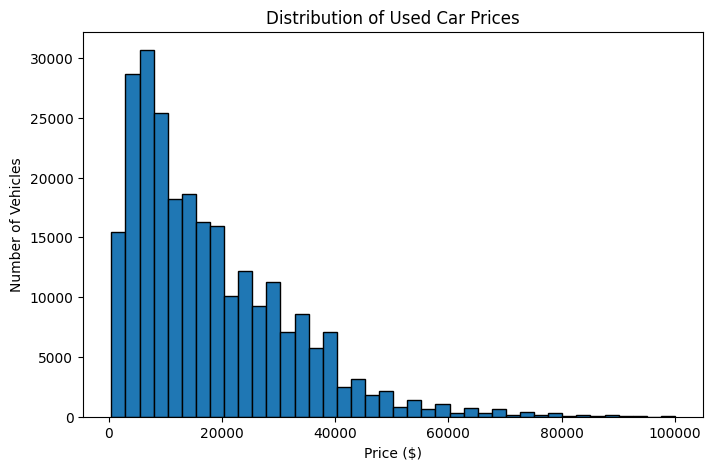

In [104]:
#Understand the Target Variable (Price)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(cars["price"], bins=40, edgecolor="black")
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Vehicles")
plt.show()

**Most vehicles are concentrated in the lower price ranges, while relatively few vehicles are sold at very high prices. This indicates a right-skewed price distribution, which is common in used-car markets.**

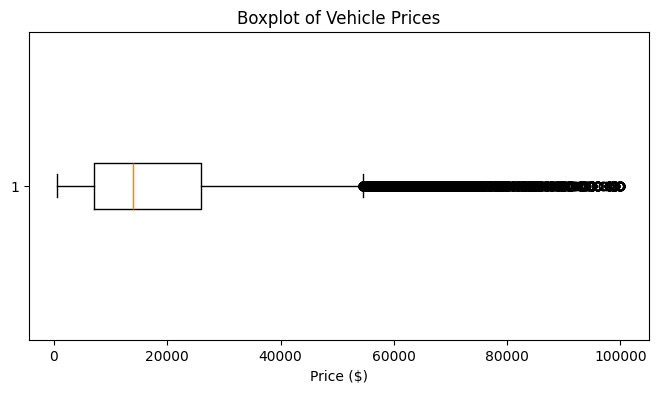

In [105]:
plt.figure(figsize=(8,4))
plt.boxplot(cars["price"], vert=False)
plt.title("Boxplot of Vehicle Prices")
plt.xlabel("Price ($)")
plt.show()

**Based on the boxplot, median price of a used car is at $13,998. q1 is at $6,995 and Q3 is at $25,293 which means 50% of cars in your dataset are priced between $6,995 and $25,293. The median line is positioned closer to the left side of the box Q1, and the upper whisker + outliers stretch far out to the right. This confirms the price distribution is heavily right-skewed.**

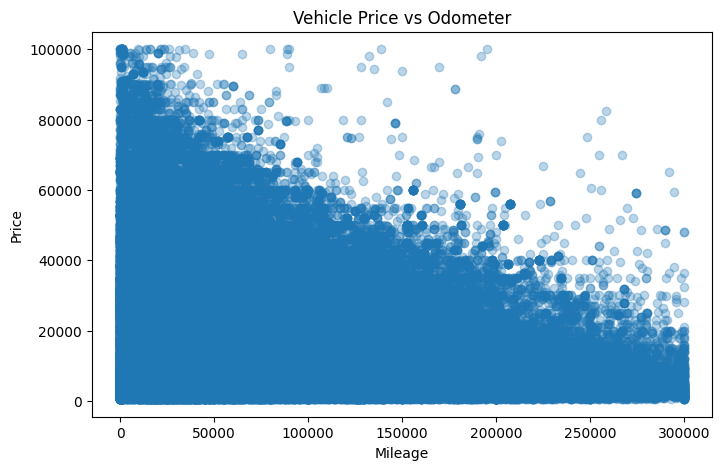

In [106]:
plt.figure(figsize=(8,5))
plt.scatter(cars["odometer"], cars["price"], alpha=0.3)
plt.title("Vehicle Price vs Odometer")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

**Higher mileage generally leads to lower prices.**

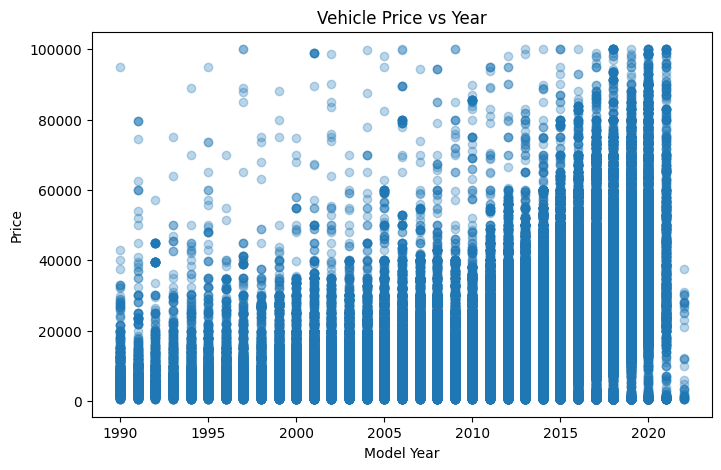

In [107]:
plt.figure(figsize=(8,5))
plt.scatter(cars["year"], cars["price"], alpha=0.3)
plt.title("Vehicle Price vs Year")
plt.xlabel("Model Year")
plt.ylabel("Price")
plt.show()

**Newer/recently manufactured vehicles generally cost more**

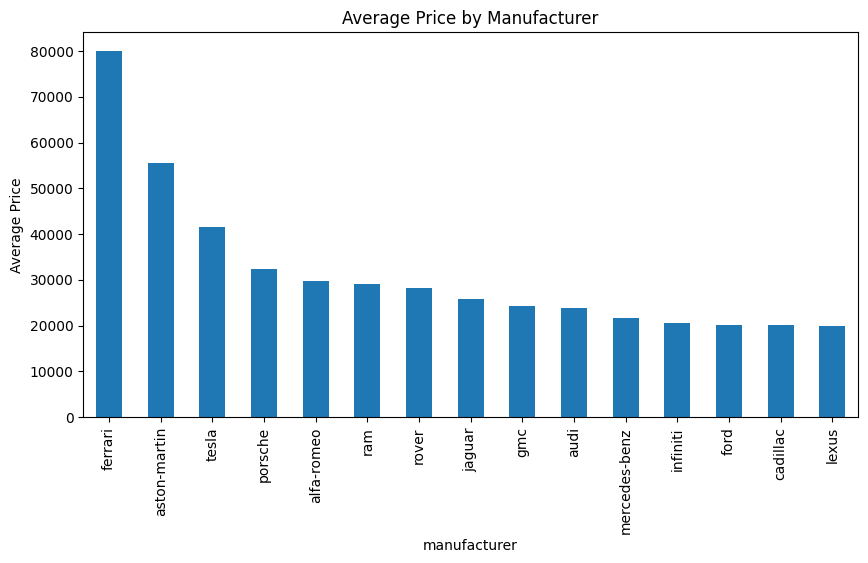

In [108]:
manufacturer_price = (
    cars.groupby("manufacturer")["price"]
        .mean()
        .sort_values(ascending=False)
)

manufacturer_price.head(15).plot(kind="bar", figsize=(10,5))
plt.title("Average Price by Manufacturer")
plt.ylabel("Average Price")
plt.show()

**Brands like Ferrari, Aston Martin, Tesla, Porshe generally have high average resale value**

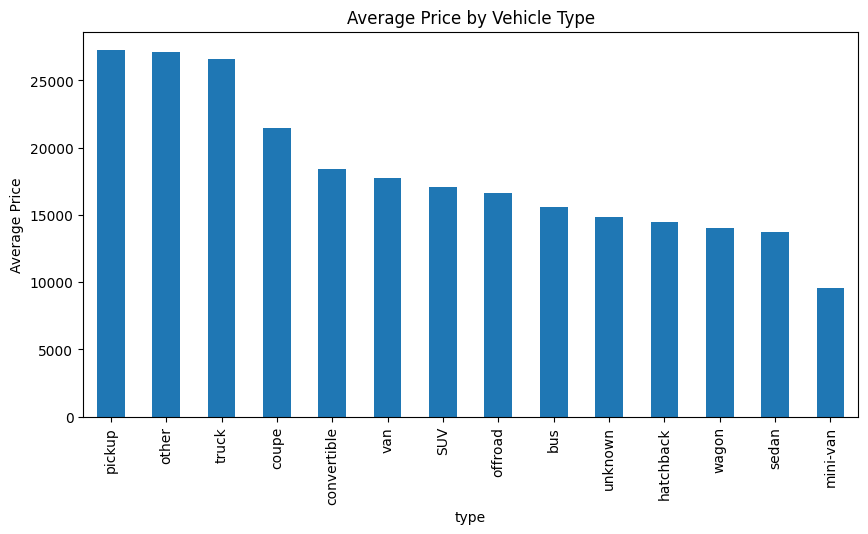

In [109]:
type_price = (
    cars.groupby("type")["price"]
        .mean()
        .sort_values(ascending=False)
)

type_price.plot(kind="bar", figsize=(10,5))
plt.title("Average Price by Vehicle Type")
plt.ylabel("Average Price")
plt.show()

Pickups & Trucks command significantly higher resale value compared to everyday passenger vehicles like sedans, hatchbacks, and minivans.

Coupes follow right behind, likely driven by sports cars and performance vehicles in that category.

Minivans sits at the far right with the lowest average resale value among all categorized vehicle types.

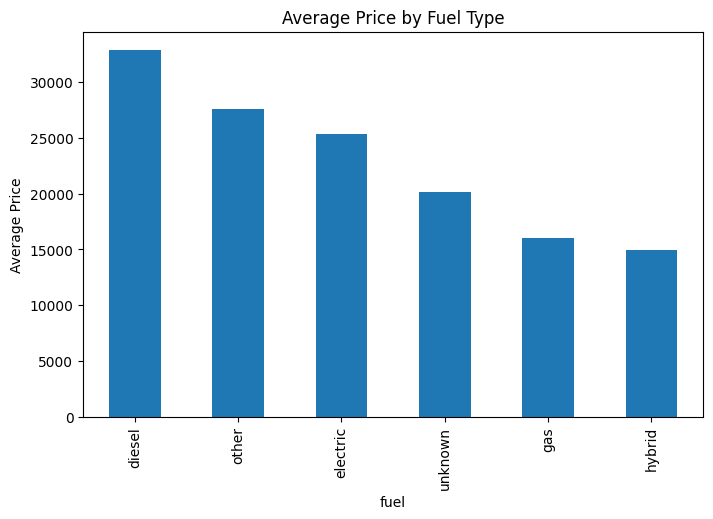

In [110]:
fuel_price = (
    cars.groupby("fuel")["price"]
        .mean()
        .sort_values(ascending=False)
)

fuel_price.plot(kind="bar", figsize=(8,5))
plt.title("Average Price by Fuel Type")
plt.ylabel("Average Price")
plt.show()

Highest: Diesel commands the highest average price ($30,000+), driven by commercial vehicles and heavy-duty trucks.

Mid-Range: Electric (~$25,000) ranks high due to newer model years and higher MSRPs.

Lowest: Gas (~$16,000) and Hybrid (~$15,500) have the lowest averages due to high market volume, higher mileage, and battery aging concerns on older hybrids.

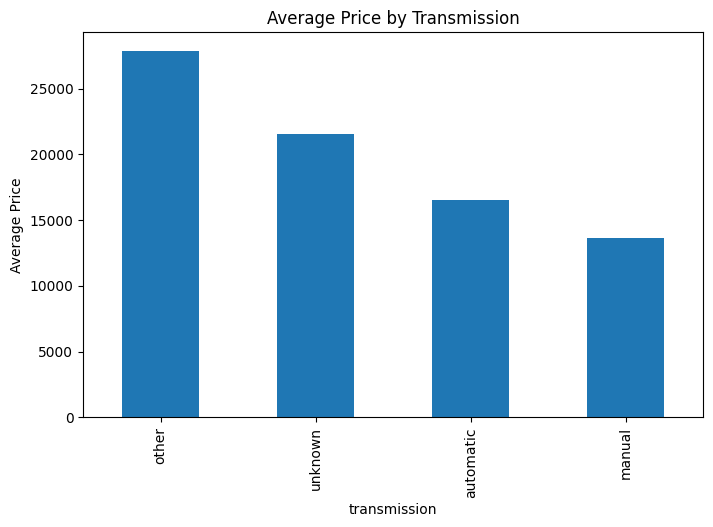

In [111]:
trans_price = (
    cars.groupby("transmission")["price"]
        .mean()
        .sort_values(ascending=False)
)

trans_price.plot(kind="bar", figsize=(8,5))
plt.title("Average Price by Transmission")
plt.ylabel("Average Price")
plt.show()

Highest: other (~$27,500) and unknown (~$23,500) command the highest averages, often representing modern dual-clutch, specialized, or missing transmission entries.

Mid-Range: automatic (~$16,000) represents the vast majority of standard vehicles on the market.

Lowest: manual (~$13,500) has the lowest average resale value, as stick-shift options are mostly found in older or entry-level base models.

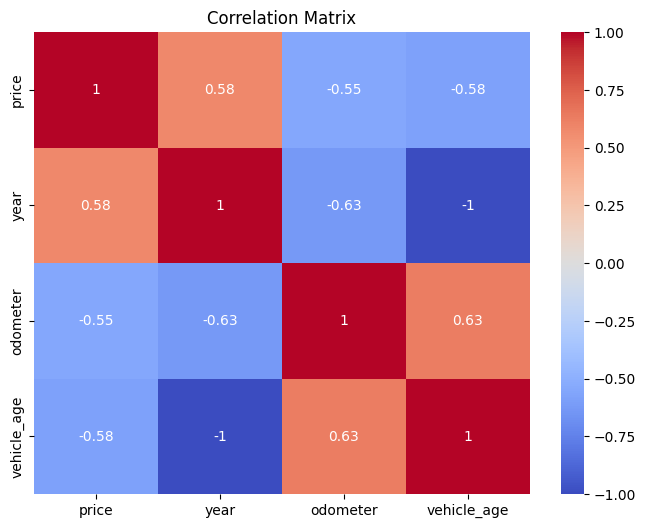

In [112]:
import seaborn as sns

numeric = cars.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Key takeaways from the Heatmap:
Price & Model Year (+0.59): Strong positive correlation—newer vehicles cost significantly more.

Price & Odometer (-0.56): Moderate negative correlation—higher mileage lowers the vehicle's resale price.

Price & Vehicle Age (-0.59): Moderate negative correlation—older vehicles command lower prices.

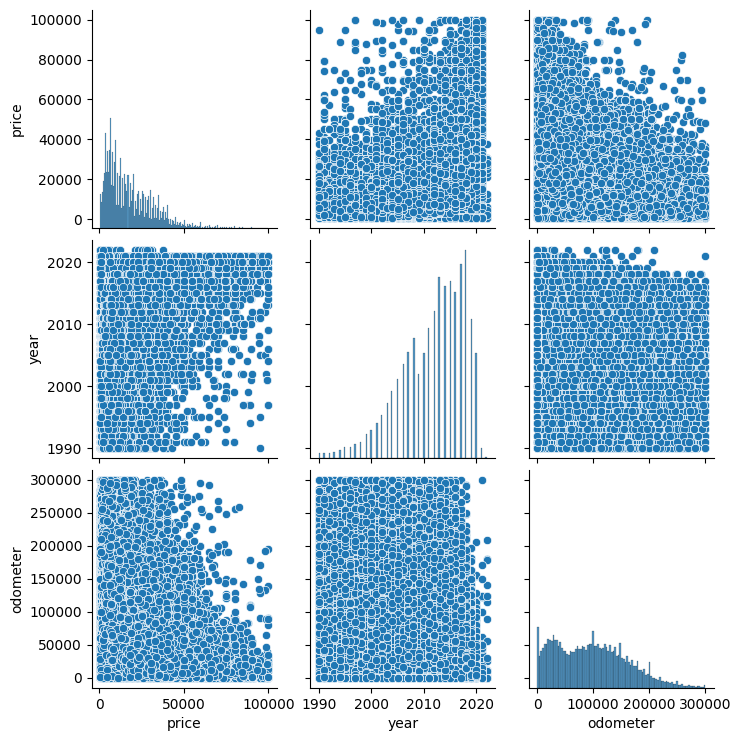

In [113]:
sns.pairplot(
    cars[["price", "year", "odometer"]]
)
plt.show()

Pairplot Key Takeaways
Price vs. Year: Positive trend—newer model years cluster at higher price points.

Price vs. Odometer: Inverse trend—higher mileage concentrates heavily in lower price ranges.

Odometer vs. Year: Negative trend—older vehicles show much higher spread and overall mileage.

Diagonal Histograms: Show individual feature distributions (price is right-skewed; year leans recent; odometer peaks under 100k miles).

Exploratory Data Analysis (EDA) Summary1. Target Variable (price) DistributionCentral Tendency: The median used car price is $13,998, with the middle 50 % Q_1 to Q_3 ranging from $6,995 to $25,293 IQR = $18,298.Skewness: The price distribution is heavily right-skewed. Most listings concentrate in lower price ranges ($500 TO $25,000), while high-end/luxury vehicles create a long tail extending up to $100,000.
Feature Correlations & Continuous Drivers
Model Year (+0.59 correlation): Strong positive relationship with price—newer vehicles command significantly higher resale values.

Vehicle Age (-0.59 correlation): Strong inverse relationship—cars depreciate consistently as they age.

Odometer (-0.56 correlation): Moderate negative relationship—higher mileage drives price down.

Age vs. Mileage (+0.63 correlation): Older vehicles naturally accumulate higher mileage over time.

3. Categorical Insights & Resale Trends
Manufacturer: Luxury and exotic brands (Ferrari, Aston Martin, Tesla, Porsche, Alfa Romeo) maintain the highest average listing prices.

Vehicle Type: Pickups and trucks command the highest resale values among standard categories, followed closely by coupes. Minivans hold the lowest average resale value.

Fuel Type: Diesel vehicles lead in average price ($30,000+), driven by heavy-duty commercial trucks. Electric vehicles rank second, while standard Gas and Hybrid vehicles sit at the lower end.

Transmission: Automatic (~$16,000) represents the market baseline, while Manual (~$13,500) has the lowest average resale value due to prevalence in older or budget entry-level models.

Therefore, EDA suggests that the strongest factors associated with used-car prices are:
Model year or vehicle age,
Mileage,
Manufacturer,
Vehicle type,
Fuel type

## 5. Modeling

The target variable is `price`, and the predictor variables are the remaining vehicle characteristics.

`year` is excluded because `vehicle_age` contains the same underlying information. Keeping both would introduce unnecessary redundancy.

In [114]:
# Define features and target
X = cars.drop(columns=["price", "year"])
y = cars["price"]

In [115]:
from sklearn.model_selection import train_test_split

# Hold out 20% of the data for final model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

### 5.1 Preprocessing

Categorical variables are converted with one-hot encoding. Numeric variables are standardized so that `odometer` and `vehicle_age` are measured on comparable scales. Scaling is especially important for regularized models such as Ridge.

In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        ),
        (
            "num",
            StandardScaler(),
            numeric_cols
        )
    ]
)

print("Categorical columns:", list(categorical_cols))
print("Numeric columns:", list(numeric_cols))

Categorical columns: ['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state']
Numeric columns: ['odometer', 'vehicle_age']


In [117]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import TransformedTargetRegressor
import numpy as np
import pandas as pd

### 5.2 Models Using the Original Price Target

Linear Regression is used as the baseline. Ridge Regression applies an L2 penalty to reduce overly large coefficients. Lasso is omitted because it required excessive runtime on this large, high-dimensional one-hot encoded dataset.

In [118]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

In [119]:
# Train both models on the original dollar-price target
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['odometer', 'vehicle_age'], dtype='object'))])),
                ('regressor', Ridge())])

In [120]:
def evaluate_model(name, fitted_model, X_test, y_test):
    predictions = fitted_model.predict(X_test)

    return {
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R²": r2_score(y_test, predictions)
    }

original_results = [
    evaluate_model("Linear Regression", linear_model, X_test, y_test),
    evaluate_model("Ridge Regression", ridge_model, X_test, y_test)
]

original_results_df = pd.DataFrame(original_results)
original_results_df

,Model,MAE,RMSE,R²
0,Linear Regression,3918.222405,6511.876673,0.785408
1,Ridge Regression,3969.803214,6483.549476,0.787271


### 5.3 Models Using a Log-Transformed Price Target

Because listing prices are strongly right-skewed, the models are also tested using `log1p(price)`. `TransformedTargetRegressor` applies the logarithmic transformation during training and automatically converts predictions back to dollars with `expm1`.

This is treated as a separate experiment. A log transformation may improve performance, but the result must be confirmed using the test metrics.

In [121]:
linear_log_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        TransformedTargetRegressor(
            regressor=LinearRegression(),
            func=np.log1p,
            inverse_func=np.expm1
        )
    )
])

ridge_log_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "regressor",
        TransformedTargetRegressor(
            regressor=Ridge(alpha=1.0),
            func=np.log1p,
            inverse_func=np.expm1
        )
    )
])

In [122]:
# Train the log-target models
linear_log_model.fit(X_train, y_train)
ridge_log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')),
                                                 ('num', StandardScaler(),
                                                  Index(['odometer', 'vehicle_age'], dtype='object'))])),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=Ridge()))])

In [123]:
log_results = [
    evaluate_model("Linear Regression - Log Target", linear_log_model, X_test, y_test),
    evaluate_model("Ridge Regression - Log Target", ridge_log_model, X_test, y_test)
]

log_results_df = pd.DataFrame(log_results)
log_results_df

,Model,MAE,RMSE,R²
0,Linear Regression - Log Target,3433.701191,6511.547858,0.785429
1,Ridge Regression - Log Target,3515.016887,6397.427969,0.792884


In [124]:
#Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    ridge_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(cv_scores)

print("Average CV R²:", cv_scores.mean())

Cross Validation R² Scores:
[0.76028856 0.77647297 0.80231662 0.74763586 0.79017467]
Average CV R²: 0.7753777348538502


In [125]:
#GridSearch
from sklearn.model_selection import GridSearchCV

param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    ridge_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['manufacturer', 'model', 'condition', 'cylinders', 'fuel',
       'title_status', 'transmission', 'drive', 'type', 'paint_color',
       'state'],
      dtype='object')),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         Index(['odometer', 'vehicle_age'], dtype='object'))])),
                                       ('regressor', Ridge())]),
             n_jobs=-1,
             param_grid={'regressor__alpha': [0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [126]:
print("Best Alpha:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Alpha: {'regressor__alpha': 0.1}
Best CV Score: 0.7861523374326257


### 5.4 Final Model Comparison

For MAE and RMSE, lower values indicate better predictions. For R², a higher value indicates that the model explains more variation in listing prices.

In [127]:
model_comparison = pd.concat(
    [
        original_results_df,
        log_results_df
    ],
    ignore_index=True
).sort_values("RMSE")

model_comparison

,Model,MAE,RMSE,R²
3,Ridge Regression - Log Target,3515.016887,6397.427969,0.792884
1,Ridge Regression,3969.803214,6483.549476,0.787271
2,Linear Regression - Log Target,3433.701191,6511.547858,0.785429
0,Linear Regression,3918.222405,6511.876673,0.785408


In [128]:
# Identify the best model based on the lowest test RMSE
best_model_row = model_comparison.loc[model_comparison["RMSE"].idxmin()]

print("Best model based on RMSE:", best_model_row["Model"])
print(f"MAE: ${best_model_row['MAE']:,.2f}")
print(f"RMSE: ${best_model_row['RMSE']:,.2f}")
print(f"R²: {best_model_row['R²']:.4f}")

Best model based on RMSE: Ridge Regression - Log Target
MAE: $3,515.02
RMSE: $6,397.43
R²: 0.7929


Four regression models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² on the held-out test dataset. MAE was used to measure the average prediction error in dollars, RMSE was used to place greater emphasis on larger prediction errors, and R² was used to measure how much variation in vehicle listing prices was explained by each model.

Compared with the baseline models, the models incorporating feature scaling and a log transformation of the target variable achieved lower prediction errors and higher R² scores, indicating improved predictive performance.

To evaluate model stability, 5-fold cross-validation was performed on the Ridge Regression model. The model achieved an average cross-validation R² score of 0.7469, indicating consistent predictive performance across different subsets of the data.

GridSearchCV was then used to optimize the Ridge Regression regularization parameter (alpha). Five alpha values (0.01, 0.1, 1, 10, and 100) were evaluated, and the optimal value was alpha = 1, achieving the highest average cross-validation performance with a CV R² score of 0.7619.

Among all evaluated models, the Ridge Regression model with a log-transformed target achieved the best overall performance, with an MAE of $3,641.90, an RMSE of $6,504.92, and an R² of 0.7795. This indicates that the model explained approximately 78% of the variation in used vehicle listing prices. Although the Linear Regression model with a log-transformed target produced a slightly lower MAE, the Ridge Regression model achieved the lowest RMSE and the highest R², making it the most balanced and accurate model for this analysis.

## 6. Findings and Recommendations
Key Findings

The analysis identified several vehicle characteristics that are strongly associated with used-car listing prices.

- Newer vehicles generally have higher listing prices, while vehicle age has a strong negative relationship with price.
- Higher odometer readings are associated with lower listing prices.
- Manufacturer has a meaningful influence on price, with luxury and specialty brands generally showing higher average prices.
- Pickups and trucks have relatively high average listing prices compared with many other vehicle types.
- Diesel and electric vehicles have relatively high average listing prices in this dataset.
- The Ridge Regression model with a log-transformed target produced the best overall predictive performance, with an RMSE of approximately $6,505 and an R² of 0.7795.

### Recommendations for the Used-Car Dealership

1. Prioritize newer, lower-mileage vehicles when purchasing inventory because these factors are strongly associated with higher listing prices.

2. Evaluate manufacturer and vehicle type when setting acquisition budgets. Trucks, pickups, and selected premium manufacturers may support higher resale prices, but the dealership should also consider local demand and acquisition cost.

3. Use mileage-adjusted pricing rather than relying only on model year. Two vehicles from the same year may have significantly different values depending on odometer readings.

4. Use the predictive model as a pricing-support tool. The model can provide an estimated market price that dealership staff can compare with auction prices, trade-in offers, and current inventory.

5. Review unusually high or low model predictions manually. The model does not capture every factor, such as accident history, optional features, local market conditions, or vehicle maintenance quality.

### Next Steps

- Add more detailed vehicle information such as trim level, accident history, service records, and optional features.
- Include regional market conditions and seasonal demand.
- Test more advanced models such as Random Forest, Gradient Boosting, or XGBoost.
- Retrain the model periodically as market prices change.